# Kenya Political Economy: Ethnic Geography and Corruption Dataset Construction

This notebook cleans and constructs county-level measures of ethnic residential sorting
and corruption perception for Kenya, combining three data sources:

- **Afrobarometer Round 6** (survey): perceived and experienced corruption at the respondent level
- **SIDE dataset** (raster): ethnic group population density grids
- **Kenya county boundaries** (GeoJSON): administrative polygon boundaries

The final dataset measures ethnic composition within and beyond 15 km of each county
capital, computes ethnolinguistic fractionalization (ELF) and total variation (TV)
distance across that boundary, and merges these with Afrobarometer corruption indices
at the county level.

The final data is a previewed with a map of Kenya, overlaid with a map of dominant ethnic groups.

This data construction is in preparation for a comparative analysis of the connection between corruption measures and ethnic similarity in Kenya and Nigeria.


*Author: James Moss*

*Date: December 2025*

*Institution: Johns Hopkins SAIS*


In [1]:
# Install required geospatial libraries.
# geopandas/shapely/fiona: vector data and spatial operations
# pyproj/rtree: CRS transformations and spatial indexing
# rasterio/rasterstats/rioxarray: raster I/O and zonal statistics
# =======

!pip -q install geopandas shapely pyogrio pyproj fiona  rtree openpyxl fuzzywuzzy rasterio rasterstats rioxarray python-levenshtein

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 887.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.0 MB/s eta 0:00:00


In [2]:
# Mount Google Drive and install/import all libraries needed for the analysis.
# =======

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import rasterio
import glob
from rasterio.crs import CRS
from rasterstats import zonal_stats
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Mounted at /content/drive


In [3]:
# Set the root directory for all input data files stored in Google Drive.

# Define the DATA_DIR
DATA_DIR = "/content/drive/MyDrive/SAISdata/"

##Loading data from drive

In [5]:
# Load all primary datasets:
#   - KenyaAfrobarometer: Afrobarometer Round 6 survey data for Kenya (xlsx format)
#   - Cities: global city dataset with lat/lng and capital status (used to identify county capitals)
#   - lgas: Kenya county boundary polygons from GeoJSON (renamed 'name' → 'adm1nm' for consistency)
#   - side_data: SIDE ethnic group raster files (.asc), stored as a dict keyed by filename.
#     Each entry holds the open rasterio reader, the raw numpy array, CRS, and affine transform.
# =======

# Loading data
#Afrobarometer round 6 Kenya
xlsx_file_name = "KEN_r6.csv.xlsx"
xlsx_file_path = os.path.join(DATA_DIR, xlsx_file_name)
KenyaAfrobarometer = pd.read_excel(xlsx_file_path)

# City locations
xlsx_file_name = "CitiesUpdated.csv"
xlsx_file_path = os.path.join(DATA_DIR, xlsx_file_name)
Cities = pd.read_csv(xlsx_file_path)

#Shapefile for kenya administrative states
geojson_path = os.path.join(DATA_DIR, "ke.json")

# Read polygon boundaries, has names and polygons
lgas = gpd.read_file(geojson_path)
lgas = lgas.to_crs("EPSG:4326")
lgas = lgas.rename(columns={"name": "adm1nm"})

# Importing ethnic data raster files from SIDE dataset
ASC_DIR = "/content/drive/MyDrive/SAISdata/SIDEKENYAASC"
asc_files = glob.glob(os.path.join(ASC_DIR, "*.asc"))

side_data = {}

for asc_path in asc_files:
    key = os.path.basename(asc_path)
    src = rasterio.open(asc_path)
    side_data[key] = {
        "src": src,         # rasterio reader
        "array": src.read(1),
        "crs": src.crs,
        "transform": src.transform
    }

In [6]:
# Preview the Kenya county boundary GeoDataFrame to confirm columns and geometry loaded correctly.
lgas.head()

,source,id,adm1nm,geometry
0,https://simplemaps.com,KE30,Baringo,"POLYGON ((35.78565 1.65613, 35.79504 1.64108, ..."
1,https://simplemaps.com,KE36,Bomet,"POLYGON ((35.58728 -0.58723, 35.58368 -0.5882,..."
2,https://simplemaps.com,KE39,Bungoma,"POLYGON ((35.01885 0.8877, 35.0192 0.88698, 35..."
3,https://simplemaps.com,KE40,Busia,"POLYGON ((34.36258 0.77716, 34.36327 0.77659, ..."
4,https://simplemaps.com,KE28,Elgeyo-Marakwet,"POLYGON ((35.69736 1.31876, 35.69758 1.31705, ..."


##cleaning the major cities dataset, creating a Kenyan state capitals dataset

In [7]:
# Clean and filter the Cities dataset to produce a GeoDataFrame of Kenyan county capitals.
#
# Steps:
#   1. Lowercase all string columns to avoid case-mismatch issues in later filtering/joins.
#   2. Convert Cities to a GeoDataFrame (gdCities) using lng/lat columns as point geometry.
#   3. Spatially join city points to county polygons (lgas) to assign each city a county name (adm1nm).
#   4. Filter to Kenya only, then filter to cities with capital == 'admin' (county/admin capitals).
#
# Result: kenyan_capitals_lga — one row per Kenyan county capital with its county assignment.
# =======

#Making the Kenyan cities/capital status/location dataset
Cities.columns = [col.lower() for col in Cities.columns]

# Clean up whitespace country
Cities['country'] = Cities['country'].str.strip().str.lower()
Cities['city'] = Cities['city'].str.strip().str.lower()
Cities['city_ascii'] = Cities['city_ascii'].str.strip().str.lower()
Cities['iso2'] = Cities['iso2'].str.strip().str.lower()
Cities['iso3'] = Cities['iso3'].str.strip().str.lower()
Cities['admin_name'] = Cities['admin_name'].str.strip().str.lower()
Cities['capital'] = Cities['capital'].str.strip().str.lower()

gdCities = gpd.GeoDataFrame(
    Cities,
    geometry=gpd.points_from_xy(Cities['lng'], Cities['lat']),
    crs="EPSG:4326"
)

Cities_with_lga = gpd.sjoin(
    gdCities,
    lgas[["adm1nm", "geometry"]],
    how="left",
    predicate="within"
)

# Filter for Kenya after cleaning
kenyan_cities_with_lga = Cities_with_lga[Cities_with_lga['country'] == 'kenya']
kenyan_capitals_lga=kenyan_cities_with_lga[kenyan_cities_with_lga['capital'] == 'admin']

##Adding capital location to the state dataset

In [8]:
# Join capital city coordinates to the county (state) polygons.
#
# Steps:
#   1. Ensure both GDFs are in WGS84 (EPSG:4326). Rename 'adm1nm' → 'state_name' in states.
#   2. Spatial join: find which state polygon each capital point falls within.
#   3. Drop duplicate capitals per state (keep one capital per county).
#   4. Left-merge capital lat/lng back onto the state polygon GDF (state geometry is preserved).
#
# Result: states_with_capitals — county polygons enriched with their capital city name and coordinates.
# =======

# STEP 1 — Matching CRS
states_gdf = lgas.to_crs("EPSG:4326")
capitals_gdf = kenyan_capitals_lga.to_crs("EPSG:4326")

states_gdf = states_gdf.rename(
    columns={"adm1nm": "state_name"}
)

# STEP 2 — Spatial join: does the capital fall inside the state polygon?
capital_states = gpd.sjoin(
    capitals_gdf[["city", "lat", "lng", "geometry"]],
    states_gdf[["state_name", "geometry"]],
    how="left",
    predicate="within"
)

# Clean up
capital_states = capital_states.drop(columns=["index_right"], errors="ignore")

# STEP 3 — One capital per state
capital_coords = (
    capital_states[["state_name", "city", "lat", "lng"]]
    .drop_duplicates(subset=["state_name"])
)

# STEP 4 — Merge back into the STATES dataset (keeping *state* geometry!)
states_with_capitals = states_gdf.merge(
    capital_coords,
    on="state_name",
    how="left"
)

##Adding ethnicity to the state dataset, both within 15 km of the capital and outside of 15 km

In [19]:
# ── ETHNICITY-BY-DISTANCE PIPELINE ──
# Computes ethnic population proportions within and beyond 15 km of each county capital.
# This is the core spatial analysis step — results feed all downstream ethnic metrics.
#
# Overview:
#   1. Confirm states_with_capitals is in WGS84; create a Point geometry for each capital.
#   2. Reproject to UTM Zone 37N (EPSG:32637, metric) to draw accurate 15 km buffers.
#   3. Intersect/difference each county polygon with its capital buffer to get
#      area_within15 (≤15 km from capital) and area_outside15 (>15 km from capital).
#   4. Reproject buffer geometries back to WGS84 to match SIDE raster coordinates.
#   5. Load SIDE metadata CSV; build eth_map: {sideid → groupname} for Kenya ethnic layers.
#   6. Define safe_zonal_stats(): clips geometry to raster bounding box before computing
#      zonal sums, preventing errors when a county extends beyond a raster's coverage.
#   7. Main loop: for each SIDE raster × each county, compute sum of ethnic density
#      inside and outside the 15 km buffer. Collect results into a flat list of dicts.
#   8. Convert results to df_eth, then aggregate by (state_name, ethnicity):
#      sum densities, compute total density per state, and divide to get proportions
#      (pct_within_15km, pct_outside_15km).
#   9. Identify states where all outside values are zero (likely no SIDE raster coverage
#      outside the buffer area); store as missing_outside_states for later NaN-flagging.
#  10. Merge df_eth_avg back onto states_with_capitals to produce final_avg.
# =======

# FULL ETHNICITY-BY-DISTANCE PIPELINE

# 1. Ensure CRS for states_with_capitals (WGS84)

if states_with_capitals.crs is None:
    states_with_capitals = states_with_capitals.set_crs("EPSG:4326")
else:
    states_with_capitals = states_with_capitals.to_crs("EPSG:4326")

# Create capital point geometry in WGS84 (does NOT replace state geometry)
states_with_capitals["capital_geom"] = gpd.points_from_xy(
    states_with_capitals["lng"],
    states_with_capitals["lat"],
    crs="EPSG:4326"
)

# 2. Make a temporary metric copy for 15 km buffers (UTM 32N)

# Reproject states and capitals to a metric CRS
states_utm = states_with_capitals.to_crs("EPSG:32637")
capital_utm = states_with_capitals["capital_geom"].to_crs("EPSG:32637")

states_utm["capital_geom_utm"] = capital_utm

BUFFER_METERS = 15000  # 15 km

# 15 km buffer around capitals (in meters)
states_utm["cap_buffer"] = states_utm["capital_geom_utm"].buffer(BUFFER_METERS)

# Split state polygons into within/outside buffer (still in UTM)
states_utm["area_within15_utm"] = states_utm.geometry.intersection(states_utm["cap_buffer"])
states_utm["area_outside15_utm"] = states_utm.geometry.difference(states_utm["cap_buffer"])

# 3. Reproject buffer geometries back to WGS84 and attach to main GDF

# Build GeoSeries with correct CRS before transforming back
within_utm = gpd.GeoSeries(states_utm["area_within15_utm"], crs="EPSG:32637")
outside_utm = gpd.GeoSeries(states_utm["area_outside15_utm"], crs="EPSG:32637")

# Reproject to WGS84 to match rasters (SIDE grid is in lat/lon)
within_wgs = within_utm.to_crs("EPSG:4326")
outside_wgs = outside_utm.to_crs("EPSG:4326")

# Attach to original states_with_capitals (which is in EPSG:4326)
states_with_capitals["area_within15"] = within_wgs
states_with_capitals["area_outside15"] = outside_wgs

# 4. Load SIDE metadata and build ethnicity mapping

csv_path = os.path.join(DATA_DIR, "side_v1_metadata.csv")
side_meta = pd.read_csv(csv_path)

# Filter for Kenya ethnic layers
side_ke = side_meta[
    (side_meta["country"] == "Kenya") &
    (side_meta["marker"] == "ethnic")
]

eth_map = dict(zip(side_ke["sideid"], side_ke["groupname"]))

def raster_key_to_ethnicity(key):
    base = key.replace(".asc", "")
    return eth_map.get(base, "UNKNOWN")

# 5. Safe zonal stats helper

def safe_zonal_stats(geom, arr, transform, raster,
                     stats="sum",
                     nodata=None):
    """
    Clips geometry to raster bounds to avoid NaN row/col errors.
    Returns zonal statistic or None if geometry empty or outside raster.
    Assumes geom is in same CRS as raster (here: EPSG:4326).
    """
    if geom is None or geom.is_empty:
        return None

    # Raster bounding box as shapely polygon
    rb = raster.bounds
    raster_box = box(rb.left, rb.bottom, rb.right, rb.top)

    # Clip geometry to raster coverage
    clipped = geom.intersection(raster_box)
    if clipped.is_empty:
        return None

    # Compute zonal stats
    zs = zonal_stats(
        clipped,
        arr,
        affine=transform,
        stats="sum",
        nodata=-9999
    )[0][stats]

    return zs

# 6. Main zonal statistics loop

results = []

for key, d in side_data.items():
    raster = d["src"]
    arr = d["array"]
    transform = d["transform"]
    raster_crs = d["crs"]

    # SIDE rasters have CRS=None but bounds clearly in lat/lon → EPSG:4326
    if raster_crs is None:
        raster_crs = CRS.from_epsg(4326)

    # Sanity check: we expect WGS84 here

    ethnicity = raster_key_to_ethnicity(key)

    # We assume states_with_capitals and SIDE rasters are both in EPSG:4326 now.
    for idx, row in states_with_capitals.iterrows():
        geom_in = row["area_within15"]
        geom_out = row["area_outside15"]

        zs_in = safe_zonal_stats(
            geom_in, arr, transform,
            raster=raster, stats="sum", nodata=None
        )

        zs_out = safe_zonal_stats(
            geom_out, arr, transform,
            raster=raster, stats="sum", nodata=None
        )

        results.append({
            "state_name": row["state_name"],
            "ethnicity": ethnicity,
            "pct_within_15km": zs_in,
            "pct_outside_15km": zs_out,
            "sideid": key.replace(".asc", ""),

        })

# 7. Convert results to DataFrame and merge

df_eth = pd.DataFrame(results)


# ID states with no raster coverage:
# 1. Sum density across rasters for EACH state + ethnicity
df_eth_sum = (
    df_eth.groupby(['state_name','ethnicity'], as_index=False)
          .agg({
              'pct_within_15km': 'sum',
              'pct_outside_15km': 'sum'
          })
          .rename(columns={
              'pct_within_15km':'sum_within',
              'pct_outside_15km':'sum_outside'
          })
)

# 2. Compute total density within/outside for each state
df_eth_sum['total_within'] = df_eth_sum.groupby('state_name')['sum_within'].transform('sum')
df_eth_sum['total_outside'] = df_eth_sum.groupby('state_name')['sum_outside'].transform('sum')

# 3. Convert density sums to proportions
df_eth_sum['pct_within_15km']  = df_eth_sum['sum_within'] / df_eth_sum['total_within']
df_eth_sum['pct_outside_15km'] = df_eth_sum['sum_outside'] / df_eth_sum['total_outside']
df_eth_avg=df_eth_sum.copy()
final = states_with_capitals.merge(df_eth, on="state_name")


# 4. Identify states where outside values are essentially all zero
state_all_zero_outside = (
    df_eth_avg.groupby("state_name")["pct_outside_15km"]
    .apply(lambda s: (s == 0).all())
)

missing_outside_states = state_all_zero_outside[
    state_all_zero_outside
].index.tolist()


final_avg = states_with_capitals.merge(df_eth_avg, on='state_name')

##Creating a state observation level DF, with measures of ethnic dominance and fractionalization

In [10]:
# Build state-level summary variables from the ethnic proportion data (df_eth_avg).
#
# 1. Clip proportions to [0, inf) to eliminate any small negative values from floating-point error.
#
# 2. Dominant group INSIDE (≤15 km of capital):
#    - Drop rows with NaN inside proportions, then find the row with the highest pct_within_15km
#      per state. Retain also the dominant-inside group's proportion OUTSIDE for comparison.
#    - Compute dominant_inside_diff = inside pct − same group's outside pct
#      (positive = group is more concentrated near the capital).
#
# 3. Dominant group OUTSIDE (>15 km of capital):
#    - Same logic, but using pct_outside_15km as the selection criterion.
#    - Compute dominant_outside_diff = outside pct − same group's inside pct.
#
# 4. Ethnolinguistic Fractionalization (ELF) inside and outside:
#    ELF = 1 − Σ(p_i²), where p_i are ethnic group proportions.
#    Higher ELF = more diversity. Computed separately for within and beyond 15 km.
#    States in missing_outside_states have their elf_outside forced to NaN.
#
# 5. Assemble state_level DataFrame:
#    Start from unique state/capital pairs, then left-merge dominant-group tables,
#    ELF, and compute:
#      - dominant_switch_indicator: 1 if the dominant group differs inside vs. outside.
#      - elf_difference: elf_inside − elf_outside.
#      - tv_distance: Total Variation distance = 0.5 * Σ|p_inside − p_outside| across
#        all ethnic groups. Measures overall shift in ethnic composition across the 15 km boundary.
# =======

# df_eth_avg must contain:
#   state_name, ethnicity, pct_within_15km, pct_outside_15km
#  clip to avoid negatives
df_eth_avg['pct_within_15km'] = df_eth_avg['pct_within_15km'].clip(lower=0)
df_eth_avg['pct_outside_15km'] = df_eth_avg['pct_outside_15km'].clip(lower=0)

# 1. Dominant groups INSIDE (15 km)

valid_in = df_eth_avg.dropna(subset=['pct_within_15km'])

idx_in = (
    valid_in
    .groupby("state_name")["pct_within_15km"]
    .idxmax()
)

dom_in = (
    valid_in.loc[idx_in]
    .rename(columns={
        'ethnicity': 'dominant_ethnicity_inside',
        'pct_within_15km': 'dominant_inside_pct',
        'pct_outside_15km': 'dominant_inside_outside_pct'
    })
    [['state_name', 'dominant_ethnicity_inside',
      'dominant_inside_pct', 'dominant_inside_outside_pct']]
)

# 2. Dominant groups OUTSIDE (> 15 km)

valid_out = df_eth_avg.dropna(subset=['pct_outside_15km'])

idx_out = (
    valid_out
    .groupby("state_name")["pct_outside_15km"]
    .idxmax()
)

dom_out = (
    valid_out.loc[idx_out]
    .rename(columns={
        'ethnicity': 'dominant_ethnicity_outside',
        'pct_outside_15km': 'dominant_outside_pct',
        'pct_within_15km': 'dominant_outside_inside_pct'
    })
    [['state_name', 'dominant_ethnicity_outside',
      'dominant_outside_pct', 'dominant_outside_inside_pct']]
)

# Differences
dom_in['dominant_inside_diff'] = (
    dom_in['dominant_inside_pct'] - dom_in['dominant_inside_outside_pct']
)

dom_out['dominant_outside_diff'] = (
    dom_out['dominant_outside_pct'] - dom_out['dominant_outside_inside_pct']
)

# 3. Ethnic fractionalization (ELF) inside / outside

#ethnolinguistic fractionalization calculation
elf = (
    df_eth_avg
    .groupby("state_name")
    .apply(lambda g: pd.Series({
        "elf_inside": 1 - np.nansum((g['pct_within_15km'])**2),
        "elf_outside": 1 - np.nansum((g['pct_outside_15km'])**2)
    }))
    .reset_index()
)

# force ELF outside to NaN when no coverage
elf.loc[
    elf['state_name'].isin(missing_outside_states),
    'elf_outside'
] = np.nan

# 4. Build state-level dataset

# start from unique states + capitals
state_level = (
    states_with_capitals[['state_name', 'city']]
    .drop_duplicates('state_name')
    .rename(columns={'city': 'capital'})
)

# left-join each piece (some states may miss dom_in or dom_out if all values were NaN)
state_level = (
    state_level
    .merge(dom_in, on='state_name', how='left')
    .merge(dom_out, on='state_name', how='left')
    .merge(elf, on='state_name', how='left')
)

# indicator if dominant group differs inside vs outside
state_level['dominant_switch_indicator'] = (
    state_level['dominant_ethnicity_inside'] != state_level['dominant_ethnicity_outside']
).astype(int)

# ELF difference
state_level['elf_difference'] = (
    state_level['elf_inside'] - state_level['elf_outside']
)

# Compute TV distance for each state
tv_distance = (
    df_eth_avg
    .assign(abs_diff=lambda x: np.abs(x['pct_within_15km'] - x['pct_outside_15km']))
    .groupby('state_name')['abs_diff']
    .sum()
    .mul(0.5)   # multiply by 1/2
    .reset_index(name='tv_distance')
)

# Merge into state-level dataset
state_level = state_level.merge(tv_distance, on='state_name', how='left')

/tmp/ipykernel_764/271005610.py:92: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


##Merging Afrobarometer with lga (admin levels) data

In [11]:
# Convert the Afrobarometer survey data to a GeoDataFrame using respondent GPS coordinates.
# Spatially join to county polygons to assign each respondent to a Kenya county (adm1nm).
# Result stored as ab_regions (respondents with county labels).
# =======

#making AB geodataframe
ab_gdf = gpd.GeoDataFrame(
    KenyaAfrobarometer,
    geometry = gpd.points_from_xy(KenyaAfrobarometer.longitude, KenyaAfrobarometer.latitude),
    crs = "EPSG:4326"   # WGS84
)

#joining
joined = gpd.sjoin(
    ab_gdf,
    lgas[["adm1nm", "geometry"]],
    how="left",
    predicate="within"
)
ab_regions=joined

##Merging capital cities and afrobarometer, distance to capital

In [12]:
# Compute two distance-to-capital measures for each Afrobarometer respondent.
#
# Both use EPSG:3857 (Web Mercator, meters) for Euclidean distance computation.
#
# 1. Nearest capital overall (any county):
#    Uses gpd.sjoin_nearest to find the closest county capital regardless of county boundaries.
#    Assigns: nearest_capital_overall, nearest_capital_overall_population,
#             dist_to_nearest_capital_overall_km.
#
# 2. Capital of the respondent's own county (same-state capital):
#    Merges on adm1nm so each respondent is matched to their own county's capital.
#    Euclidean distance computed between respondent point and merged capital geometry.
#    Assigns: nearest_capital_same_state, population, lat/lng of that capital,
#             dist_to_nearest_capital_same_state_km.
#
# Results are written back to ab_gdf (overall) and ab_regions (same-state),
# which refer to different but related GeoDataFrames.
# =======

# Project to a metric CRS (Web Mercator, meters)
ab_proj = ab_regions.to_crs("EPSG:3857")
capitals_proj = kenyan_capitals_lga.to_crs("EPSG:3857")

# Drop 'index_right' if it exists in capitals_proj to prevent column name conflict
if 'index_right' in ab_proj.columns:
    ab_proj = ab_proj.drop(columns='index_right')
if 'index_right' in capitals_proj.columns:
    capitals_proj = capitals_proj.drop(columns='index_right')

# Making a column for nearest capital (overall, not necessarily in the same state)#
nearest_overall = gpd.sjoin_nearest(
    ab_proj,
    capitals_proj[['city', 'adm1nm', 'geometry', 'population']],
    how="left",
    distance_col="dist_to_capital_overall_m"
)

ab_gdf['nearest_capital_overall'] = nearest_overall['city'].values
ab_gdf['nearest_capital_overall_population'] = nearest_overall['population'].values
ab_gdf['dist_to_nearest_capital_overall_km'] = (
    nearest_overall['dist_to_capital_overall_m'].values / 1000.0
)

# Capital in the same state
# Merge on state name
same_state = ab_proj.merge(
    capitals_proj[['adm1nm', 'city', 'geometry', 'population','lat','lng']],
    on='adm1nm',
    how='left',
    suffixes=('', '_capital')
)

# Distance from respondent to their state's capital
same_state['dist_to_capital_same_state_m'] = same_state.geometry.distance(
    same_state['geometry_capital']
)

# Bring back to original ab_regions
ab_regions['nearest_capital_same_state'] = same_state['city'].values
ab_regions['nearest_capital_same_state_population'] = same_state['population'].values
ab_regions['nearest_capital_same_state_lat'] = same_state['lat'].values
ab_regions['nearest_capital_same_state_lng'] = same_state['lng'].values

ab_regions['dist_to_nearest_capital_same_state_km'] = (
    same_state['dist_to_capital_same_state_m'].values / 1000.0
)

##Adding afrobarometer data to state_level (avg corruption indexes)

In [13]:
# Construct perceived and experienced corruption indices at the county level
# from Afrobarometer Round 6 survey questions, then merge onto state_level.
#
# Variables:
#   perceived_vars (q53a–q53j): Afrobarometer questions on perceived corruption
#     among various public officials (president's office, MPs, local officials, police, etc.).
#     Note: q53l/m/n (state-level government) are excluded from the source data.
#   experienced_vars (q55b,d,f,h,j,l): Questions asking whether the respondent personally
#     paid a bribe to access various public services in the past year.
#     (An earlier version with q55c/j/l is overwritten by the recalculated version below it.)
#
# Cleaning:
#   - Code 7 in experienced vars = 'no contact with this service' → treated as missing (NaN).
#   - Codes 8, 9, 77, 88, 99 = various 'don't know / refused / not applicable' → NaN.
#
# Aggregation:
#   1. Compute county-level means for each variable separately.
#   2. Average across variables within each county to form a composite index.
#   3. Rename adm1nm → state_name for merging.
#   4. Left-merge both indices onto state_level.
# =======

# 1. Select variables

#perception of corruption among govt officials, police, and more
#q53l,m,n is specifically for state govt but not included in this data
perceived_vars = [
    'q53a','q53b','q53c','q53d','q53e',
    'q53f','q53g','q53h','q53i','q53j'
]

#experienced corruption variables
experienced_vars = ['q55b','q55d','q55f','q55h', 'q55j', 'q55l']

# 2. CLEANING

ab = ab_regions.copy()

# Convert "no contact" in experienced vars to np.nan
ab[experienced_vars] = ab[experienced_vars].replace({7: np.nan})

# Replace special missing codes
missing_codes = [8,9,77,88,99]
ab[perceived_vars] = ab[perceived_vars].replace(missing_codes, np.nan)
ab[experienced_vars] = ab[experienced_vars].replace(missing_codes, np.nan)

# 3. STATE-LEVEL AGGREGATION

# Group datasets by state name column (`adm1nm`)
df_state_perceived = (
    ab.groupby('adm1nm')[perceived_vars]
      .mean()
      .reset_index()
)

df_state_experienced = (
    ab.groupby('adm1nm')[experienced_vars]
      .mean()
      .reset_index()
)

# Create composite indices
df_state_perceived['perceived_corruption_index'] = (
    df_state_perceived[perceived_vars].mean(axis=1)
)

df_state_experienced['experienced_corruption_index'] = (
    df_state_experienced[experienced_vars].mean(axis=1)
)

# Keep only state + index
df_state_perceived = df_state_perceived[['adm1nm','perceived_corruption_index']]
df_state_experienced = df_state_experienced[['adm1nm','experienced_corruption_index']]

# 4. MERGE onto state_level geodataframe
#     (state_level uses 'state_name' so map appropriately)

# First ensure matching names
df_state_perceived = df_state_perceived.rename(columns={'adm1nm':'state_name'})
df_state_experienced = df_state_experienced.rename(columns={'adm1nm':'state_name'})

state_level = (
    state_level
    .merge(df_state_perceived, on='state_name', how='left')
    .merge(df_state_experienced, on='state_name', how='left')
)

In [14]:
# Apply the same missing-value cleaning to ab_regions (the respondent-level GeoDataFrame)
# and compute an individual-level experienced_corruption_index as the row-wise mean
# across the experienced corruption variables.
# =======

# Convert "no contact" in experienced vars to np.nan
ab_regions[experienced_vars] = ab_regions[experienced_vars].replace({7: np.nan})

# Replace special missing codes
missing_codes = [-1,8,9,77,88,99]
ab_regions[perceived_vars] = ab_regions[perceived_vars].replace(missing_codes, np.nan)
ab_regions[experienced_vars] = ab_regions[experienced_vars].replace(missing_codes, np.nan)

ab_regions['experienced_corruption_index']=ab_regions[experienced_vars].mean(axis=1)

##Saving intermediate dataframes

In [ ]:
# Save intermediate outputs to Google Drive for use in downstream notebooks.
#   - states_with_capitals: saved as Parquet (preserves geometry efficiently).
#   - ab_regions: saved as GeoPackage (standard format for vector geodata with attributes).
#   - state_level: saved as CSV (saved twice — the second call is a duplicate).
# =======

states_with_capitals.to_parquet(
    '/content/drive/MyDrive/SAISdata/IntermediateData/Kenya/states_with_capitalsKenya3.parquet'
)
ab_regions.to_file('/content/drive/MyDrive/SAISdata/IntermediateData/Kenya/ab_regionsKenya3.gpkg', layer='layer1', driver='GPKG')
state_level.to_csv('/content/drive/MyDrive/SAISdata/IntermediateData/Kenya/state_levelKenya3.gpkg', index=False)

# for debugging:
# allsettlements_with_lga.to_file('/content/drive/MyDrive/SAISdata/IntermediateData/Kenya/allsettlements_with_lgaKenya2.gpkg', layer='layer1', driver='GPKG')


## Data preview: Kenya Ethnic Distribution Map

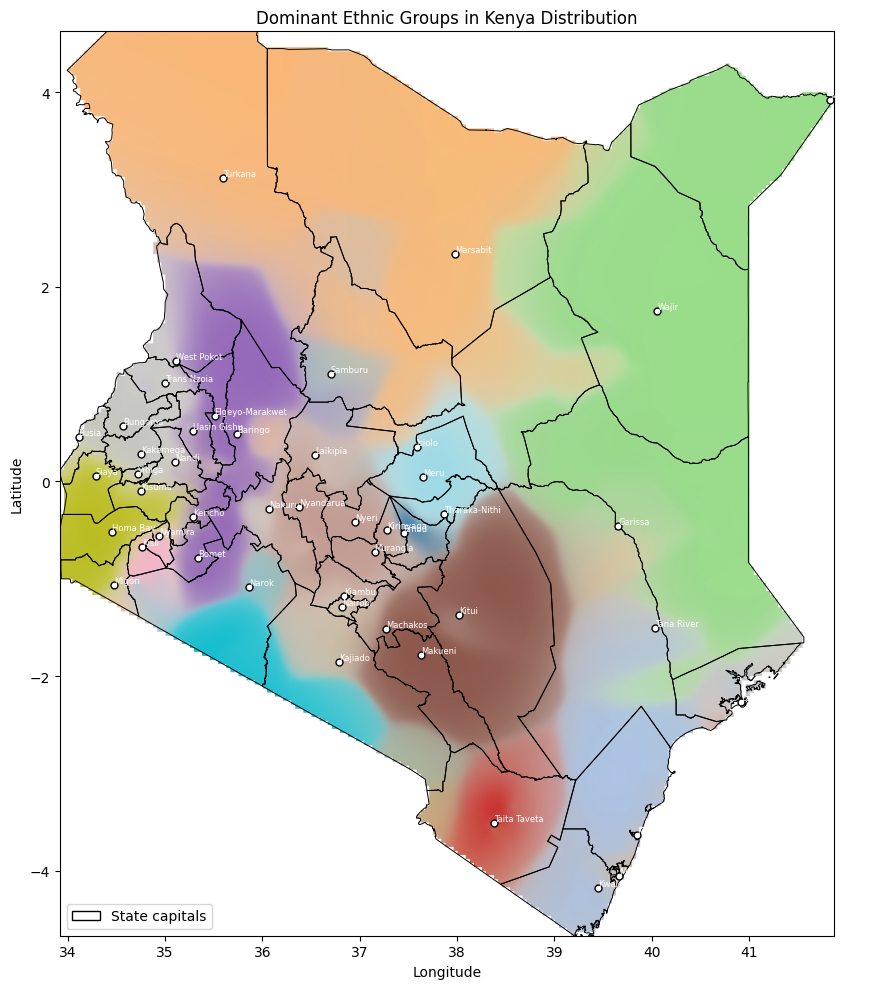

In [18]:
# Visualize the spatial distribution of ethnic groups across Kenya using SIDE raster data.
# Each ethnic group is assigned a unique color; pixel intensity drives the alpha channel
# so areas of higher ethnic density appear more opaque.
# State boundaries and county capitals are overlaid for geographic reference.
# Filters to mapid 'side_v1_117' (Kenya ethnic survey) and dissolves county polygons
# into single state polygons to produce clean, non-duplicated boundaries.

# PATHS:
ASC_DIR   = "/content/drive/MyDrive/SAISdata/SIDEKENYAASC"
META_PATH = "/content/drive/MyDrive/SAISdata/side_v1_metadata.csv"

# LOAD LGA-LEVEL STATES + CAPITALS
lgas = states_with_capitals.copy()

# Make sure CRS is WGS84
lgas = lgas.to_crs("EPSG:4326")

# Dissolve LGAs into one polygon per state, keeping first capital coords
states_for_plot = lgas.dissolve(
    by="state_name",  # column that identifies states
    aggfunc="first"   # keep first city/lat/lng per state
).reset_index()

#Load Side Metadata
meta = pd.read_csv(META_PATH)

# Filter to the Kenya survey (mapid 197 here)
kenya_groups = meta[meta["sideid"].str.contains("side_v1_117")]

# List all SIDE rasters for this mapid
asc_files = sorted(
    [f for f in os.listdir(ASC_DIR) if f.endswith(".asc") and "side_v1_117" in f]
)

# PLOT SETUP
fig, ax = plt.subplots(figsize=(10, 10))

# Color palette: one color per group
colors = plt.cm.tab20(np.linspace(0, 1, len(asc_files)))
legend_items = []
bounds = None  # will be filled from first raster

# Loop over ethnic group rasters
for i, asc in enumerate(asc_files):
    asc_path = os.path.join(ASC_DIR, asc)

    with rasterio.open(asc_path) as src:
        arr = src.read(1).astype(float)
        arr[arr == src.nodata] = np.nan
        if bounds is None:
            bounds = src.bounds

    max_val = np.nanmax(arr)
    if max_val <= 0 or np.isnan(max_val):
        continue

    alpha = arr / max_val      # intensity → transparency
    rgb_color = colors[i][:3]  # RGB from colormap

    rgba = np.zeros((arr.shape[0], arr.shape[1], 4))
    rgba[..., 0] = rgb_color[0]
    rgba[..., 1] = rgb_color[1]
    rgba[..., 2] = rgb_color[2]
    rgba[..., 3] = np.nan_to_num(alpha)

    ax.imshow(
        rgba,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper"
    )

    # Get group name from metadata for legend
    row = kenya_groups[kenya_groups["sideid"] == asc.replace(".asc", "")]
    if len(row) > 0:
        gname = row.iloc[0]["groupname"]
    else:
        gname = asc.replace(".asc", "")

    legend_items.append(mpatches.Patch(color=rgb_color, label=gname))

# Overlay State Boundaries
states_for_plot.boundary.plot(ax=ax, color="black", linewidth=0.7)

# Plot State Capitals
if {"lat", "lng"}.issubset(states_for_plot.columns):
    ax.scatter(
        states_for_plot["lng"],
        states_for_plot["lat"],
        color="white",
        edgecolor="black",
        s=25,
        zorder=5,
        label="State capitals"
    )

    # label each state near its capital
    for _, row in states_for_plot.iterrows():
        ax.text(
            row["lng"],
            row["lat"],
            str(row.get("state_name", "")),
            fontsize=6,
            color="white",
            ha="left",
            va="bottom",
            zorder=6
        )

# Legends and final styling
ax.set_xlim(bounds.left, bounds.right)
ax.set_ylim(bounds.bottom, bounds.top)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dominant Ethnic Groups in Kenya Distribution")

# Legend for ethnic groups
eth_legend = ax.legend(
    handles=legend_items,
    title="Ethnic groups",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=7
)

# Add a separate legend entry for capitals if applicable
if {"lat", "lng"}.issubset(states_for_plot.columns):
    ax.add_artist(eth_legend)
    ax.legend(
        handles=[mpatches.Patch(facecolor="white", edgecolor="black", label="State capitals")],
        loc="lower left"
    )

plt.tight_layout()
plt.show()
